# MNIST Example with Variability

In [1]:
# You dont need this, this is for my convinience
import sys
import os
notebook_dir = os.path.dirname(os.getcwd())
sys.path.append(notebook_dir)

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from nervos.utils import Module, Parameters
from nervos.dataloader import MNISTLoader

In [16]:
p = Parameters()
p.from_url('https://pastebin.com/raw/e5ka6B9p')

In [17]:
allowed_levels = np.array(
           [1.0, 0.9679310906766183, 0.93760456888016, 0.9076014969897948, 0.8791824458963751,
            0.8496445762753205, 0.8209604023080539, 0.7935519996097391, 0.7671344494652823,
            0.741995145069934, 0.7168883624137776, 0.6916196780559918, 0.6682011978604938,
            0.644600313127789, 0.62183509569345, 0.5993915606793792, 0.5773725757606286,
            0.5557031995381914, 0.5343449008210679, 0.5132156682669483, 0.49230418996654846,
            0.47142452641101046, 0.4505597804358407, 0.4297537503397992, 0.4088284856499594,
            0.3877543957690631, 0.3664585982352714, 0.34477928874249386, 0.3228929359601,
            0.30055530869670194, 0.2778102406007755, 0.254499930537807, 0.2310277187732093,
            0.20723594557133454, 0.18259118371000224, 0.15743915341670922, 0.1322747507226366,
            0.10701030833083243, 0.08075324589934445, 0.05429645756955848, 0.027605300619291628,
            0.0]
        )

In [18]:
class MNIST_SNN(Module):
    def __init__(self, parameters, identifier=None):
        super().__init__(parameters, identifier)
        self.dataloader = MNISTLoader(parameters, classes=[i for i in range(5)])
        self.X_train, self.Y_train = self.dataloader.dataloader(
            preprocess=True, pca=False, size=parameters.training_images_amount
        )
        self.X_test, self.Y_test = self.dataloader.dataloader(
            preprocess=True, train=False, pca=False, size=parameters.testing_images_amount
        )
        self.get_spikeplots = False
        
        self.allowed_levels = allowed_levels

    def predict(self, un_processed_image, model_location):
        spike_train = np.array(self.dataloader.img2spiketrain(un_processed_image))
        synapses, neuron_label_map = self.load_model(model_location)
        return self.get_prediction(spike_train, synapses, neuron_label_map)


In [19]:
m = MNIST_SNN(p, "5classmnist_with_variability")
m.initialise_layers([784, 60])
m.enable_synaptic_noise = True
m.noise_magnitude_half_range = 0.1

In [20]:
y = m.train()

Epoch 1/3
100/100 [========================================] [Max cycles for one synapse: 3486.0]
Testing...
Test set accuracy: 0.75
Time elapsed since training start: 293.538s
Epoch 2/3
100/100 [========================================] [Max cycles for one synapse: 8602.0]
Testing...
Test set accuracy: 0.95
Time elapsed since training start: 591.057s
Epoch 3/3
100/100 [========================================] [Max cycles for one synapse: 12788.0]
Testing...
Test set accuracy: 1.0
Time elapsed since training start: 877.875s
Training complete!


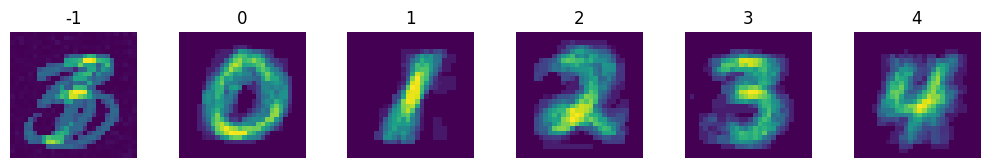

In [21]:
def visualise_synapse(synapses,labels):
    kk=28
    classes = {i:np.zeros((kk,kk)) for i in np.unique(labels)}
    for idx in range(len(synapses)):
        classes[labels[idx]]+= synapses[idx].reshape((kk,kk))
    
    i = 1
    plt.figure(figsize=(10,30))
    for k in classes.keys():
        plt.subplot(1,len(classes),i)
        plt.imshow(classes[k])
        plt.title(f"{k}")
        plt.tight_layout()
        plt.axis('off')
        i+=1
    plt.show()
    
visualise_synapse(m.learned_synapses[0],m.learned_neuron_label_map)

In [22]:
def accuracy(m2):
    spike_trains,labels = MNISTLoader(p,classes=[i for i in range(5)]).dataloader(train=False,preprocess=True,seed=123,size=1500)
    t = 0
    c = 0
    preds = []
    print('Calculating Accuracy')
    for st,label in zip(spike_trains,labels):
        pred = m2.get_prediction(st)
        preds.append(pred)
        if pred == label:
            c+=1
        t+=1
        
        print(f"\rTested {t} images",end='')
    print()
    print(c/t)
    return labels,preds

y_true,y_pred = accuracy(m)

Calculating Accuracy
Tested 1500 images
0.9033333333333333
